In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from scipy.stats import norm
from joblib import Parallel, delayed
from numba import njit
import os
from datetime import datetime
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings("ignore")

In [10]:
from simulate import LAMBDA_TAX, ALPHA_BASE, SIGMA, W_M, W_V, omega, simulate_student

In [11]:
sim_df = pd.read_csv("data/sim_results_20260520_165311_tutoring_false.csv")

### Sanity Check

In [5]:
def run_calibration_diagnostic(N=2000):
    print("RUNNING POPULATION A/B TEST")
    
    # Not Empirically Calibrated, Uniform Population
    w_uni = np.random.uniform(0.0, 1.0, N)
    eta_M_uni = np.random.uniform(1.0, 2.0, N)
    eta_V_uni = np.random.uniform(1.0, 2.0, N)
    eta_comp_uni = 0.5 * eta_M_uni + 0.5 * eta_V_uni
    
    # Empirically Calibrated Population
    w_emp = np.random.uniform(0.0, 1.0, N)
    cov_matrix = [[0.25**2, 0.70 * 0.25**2], [0.70 * 0.25**2, 0.25**2]]
    eta_M_emp, eta_V_emp = np.zeros(N), np.zeros(N)
    for i in range(N):
        mean = 1.35 + (0.40 * w_emp[i]) # 1.6 SD Gap
        draws = np.random.multivariate_normal([mean, mean], cov_matrix)
        eta_M_emp[i], eta_V_emp[i] = draws[0], draws[1]
    eta_comp_emp = 0.5 * eta_M_emp + 0.5 * eta_V_emp
    
    # Fast Approximation
    def sim_scores(eta, wealth):
        # Base SS Score (Ability + base noise)
        ss_score = eta + np.random.normal(0, 0.15, N)
        # SC Score (Ability + Mechanical Boost driven by wealth)
        # Assume wealthy take 4 attempts (boost ~0.2), poor take 1 (boost ~0)
        attempts = 1 + np.floor(wealth * 3) 
        sc_boost = np.where(attempts > 1, 0.20, 0.0)
        sc_score = ss_score + sc_boost
        return ss_score, sc_score

    ss_uni, sc_uni = sim_scores(eta_comp_uni, w_uni)
    ss_emp, sc_emp = sim_scores(eta_comp_emp, w_emp)
    
    # Calculate Algorithmic Premium
    def get_premium(ss, sc, w):
        q4_mask = w >= 0.75
        q1_mask = w <= 0.25
        ss_gap = ss[q4_mask].mean() - ss[q1_mask].mean()
        sc_gap = sc[q4_mask].mean() - sc[q1_mask].mean()
        return ss_gap, sc_gap, sc_gap - ss_gap

    uni_ss_gap, uni_sc_gap, uni_prem = get_premium(ss_uni, sc_uni, w_uni)
    emp_ss_gap, emp_sc_gap, emp_prem = get_premium(ss_emp, sc_emp, w_emp)
    
    print("\nRESULTS: UNIFORM (Old) vs EMPIRICAL (New)")
    print(f"{'Metric':<25} | {'Uniform (Uncalibrated)':<22} | {'Empirical (Calibrated)'}")
    print("-" * 75)
    print(f"{'Baseline SS Gap (Q4-Q1)':<25} | +{uni_ss_gap:<21.3f} | +{emp_ss_gap:.3f} (Reality)")
    print(f"{'Superscore Gap (Q4-Q1)':<25} | +{uni_sc_gap:<21.3f} | +{emp_sc_gap:.3f}")
    print(f"{'ALGORITHMIC PREMIUM (+Δ)':<25} | +{uni_prem:<21.3f} | +{emp_prem:.3f}")

In [6]:
run_calibration_diagnostic()

RUNNING POPULATION A/B TEST

RESULTS: UNIFORM (Old) vs EMPIRICAL (New)
Metric                    | Uniform (Uncalibrated) | Empirical (Calibrated)
---------------------------------------------------------------------------
Baseline SS Gap (Q4-Q1)   | +-0.012                | +0.299 (Reality)
Superscore Gap (Q4-Q1)    | +0.188                 | +0.499
ALGORITHMIC PREMIUM (+Δ)  | +0.200                 | +0.200


#### Calibration Proof: Wealth vs Ability Distribution

In [14]:
def plot_calibration_proof(sim_df):
    """Visualizes the structurally correlated baseline population."""
    # The population is identical across rules, so isolating one (SS)
    base_df = sim_df[sim_df['rule'] == 'SS']
    
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Hexbin plot for density
    hb = ax.hexbin(base_df['wealth_pct'], base_df['true_ability'], 
                   gridsize=20, cmap='Blues', mincnt=1, edgecolors='white', linewidths=0.5)
    cb = plt.colorbar(hb, ax=ax, label='Number of Students')
    
    # Calculate and plot the trendline
    z = np.polyfit(base_df['wealth_pct'], base_df['true_ability'], 1)
    p = np.poly1d(z)
    ax.plot(base_df['wealth_pct'], p(base_df['wealth_pct']), "r--", alpha=0.8, linewidth=2, 
            label=f'Structural Gradient (Slope: +{z[0]:.2f})')
    
    ax.set_title('Empirical Calibration: Wealth vs. True Ability', fontsize=14, fontweight='bold')
    ax.set_xlabel('Wealth Percentile', fontsize=12)
    ax.set_ylabel('True Baseline Ability (\u03B7)', fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()

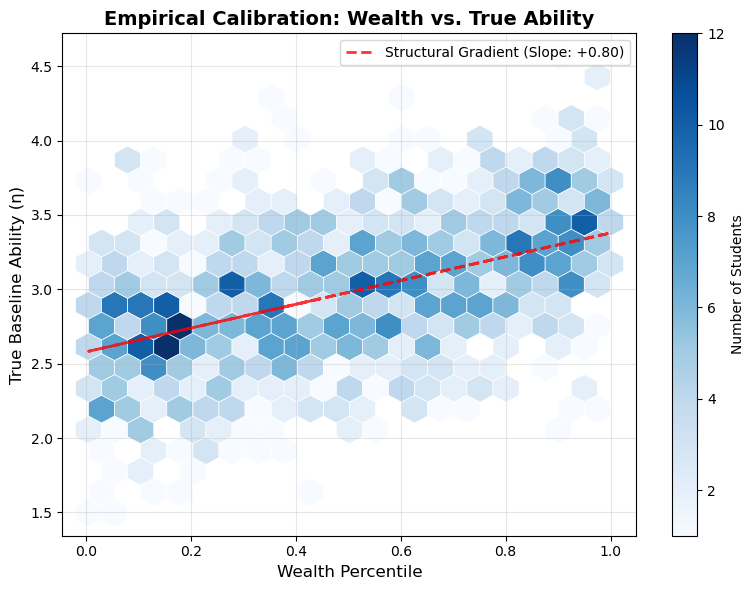

In [15]:
plot_calibration_proof(sim_df)

### Figure 1: Student Cluster Plot
X: True Ability
Y: Expected Final Score
Color: Wealth Percentile
One panel per mechanism, side by side for SS vs SC comparison

In [ ]:
def plot_cluster(sim_df):
    rules_to_show = ['SS', 'SC', 'TAX', 'FISC', 'Contextual']
    labels = {
        'SS': 'Single-Sitting',
        'SC': 'Superscoring',
        'TAX': f'Variance Tax (λ={LAMBDA_TAX})',
        'FISC': 'Full Info Superscoring',
        'Contextual': 'Contextual Correction'
    }
    fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
    cmap = plt.get_cmap('RdYlGn')
    
    for ax, rule in zip(axes, rules_to_show):
        sub = sim_df[sim_df['rule'] == rule]
        sc = ax.scatter(
            sub['true_ability'],
            sub['mean_score'],
            c=sub['wealth_pct'],
            cmap=cmap, vmin=0, vmax=1,
            s=40, alpha=0.8, edgecolors='none'
        )
        
        ax.set_title(labels[rule], fontsize=11, fontweight='bold')
        ax.set_xlabel('True Ability (η_M + η_V)', fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel('Expected Final Score', fontsize=9)
        ax.legend(fontsize=7)

    plt.colorbar(sc, ax=axes[-1], label='Wealth Percentile\n(0=Low, 1=High)')
    plt.suptitle(
        'Figure 1: Student Cluster Plot — Ability vs. Submitted Score by Wealth\n',
        fontsize=12, y=1.02
    )
    plt.tight_layout()

    plt.savefig('graphs_results/fig1_cluster_plot.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Fig 1 saved.")

In [15]:
plot_cluster(sim_df)

Fig 1 saved.


#### Fig 1a + 1b: Student Cluster Plot Normalized by True Ability, Conditioned on Acceptance

% of total admitted group belong to each quartile.

\# students admitted for each quantile / total admitted students

In [ ]:
def plot_split_admissions_clean(sim_df, top_pct=0.10):
    rules_to_show = ['SS', 'SC', 'TAX', 'FISC', 'Contextual']
    labels = {
        'SS': 'Single-Sitting',
        'SC': 'Superscoring',
        'TAX': 'Variance Tax',
        'FISC': 'Full Info Superscoring',
        'Contextual': 'Contextual Correction'
    }
    
    # Calculate normalization and demographic table
    print(f"DEMOGRAPHIC BREAKDOWN OF ADMITTED STUDENTS (TOP {top_pct*100:.0f}%)")

    quartile_labels = ['Q1 (Lowest)', 'Q2', 'Q3', 'Q4 (Highest)']
    
    # wealth quartiles
    if 'wealth_quartile' not in sim_df.columns:
        sim_df['wealth_quartile'] = pd.qcut(sim_df['wealth_pct'], q=4, labels=quartile_labels)
    
    plot_df = sim_df.copy()
    plot_df['distance_from_cutoff'] = 0.0
    plot_df['is_admitted'] = False
    
    table_rows = []
    
    for rule in rules_to_show:
        mask = plot_df['rule'] == rule
        
        # Calculate the cutoff and normalize
        cutoff = plot_df.loc[mask, 'mean_score'].quantile(1 - top_pct)
        plot_df.loc[mask, 'distance_from_cutoff'] = plot_df.loc[mask, 'mean_score'] - cutoff
        plot_df.loc[mask, 'is_admitted'] = plot_df.loc[mask, 'distance_from_cutoff'] >= 0
        
        # Calculate demographics for the table
        admitted_subset = plot_df[mask & plot_df['is_admitted']]
        
        if len(admitted_subset) > 0:
            demo_pct = (admitted_subset['wealth_quartile']
                        .value_counts(normalize=True)
                        .reindex(quartile_labels, fill_value=0.0) * 100)
            
            row_data = {'Mechanism': labels[rule]}
            for quart in quartile_labels:
                row_data[quart] = f"{demo_pct[quart]:.1f}%"
                
            table_rows.append(row_data)
            
    demo_df = pd.DataFrame(table_rows)
    demo_df = demo_df[['Mechanism'] + quartile_labels]
    print("\n" + demo_df.to_string(index=False) + "\n")
    
    csv_filename = f'graphs_results/admitted_demographics_top_{int(top_pct*100)}pct.csv'
    demo_df.to_csv(csv_filename, index=False)
    print(f"Successfully saved full table to '{csv_filename}'")

    cmap = plt.get_cmap('RdYlGn')
    
    # GRAPH 1: ADMITTED STUDENTS ONLY
    fig1, axes1 = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
    for col, rule in enumerate(rules_to_show):
        sub = plot_df[(plot_df['rule'] == rule) & (plot_df['is_admitted'] == True)]
        
        sc1 = axes1[col].scatter(
            sub['true_ability'], sub['distance_from_cutoff'],
            c=sub['wealth_pct'], cmap=cmap, vmin=0, vmax=1,
            s=40, alpha=0.8, edgecolors='black', linewidth=0.5
        )
        axes1[col].set_title(labels[rule], fontsize=12, fontweight='bold')
        axes1[col].set_xlabel('True Ability', fontsize=10)
    
    axes1[0].set_ylabel('Points Above Cutoff', fontsize=11, fontweight='bold')
    cbar_ax1 = fig1.add_axes([0.93, 0.15, 0.012, 0.7])
    fig1.colorbar(sc1, cax=cbar_ax1, label='Wealth Percentile')
    plt.suptitle(f'Figure 1A: Admitted Student Clusters (Top {top_pct*100:.0f}%)', fontsize=14, fontweight='bold', y=1.02)
    plt.savefig(f'graphs_results/fig1a_admitted_pool_{top_pct*100:.0f}%.png', dpi=150, bbox_inches='tight')
    plt.close()
    
    # GRAPH 2: REJECTED STUDENTS ONLY
    fig2, axes2 = plt.subplots(1, 5, figsize=(22, 4.5), sharey=True)
    for col, rule in enumerate(rules_to_show):
        sub = plot_df[(plot_df['rule'] == rule) & (plot_df['is_admitted'] == False)]
        
        sc2 = axes2[col].scatter(
            sub['true_ability'], sub['distance_from_cutoff'],
            c=sub['wealth_pct'], cmap=cmap, vmin=0, vmax=1,
            s=40, alpha=0.8, edgecolors='black'
        )
        axes2[col].set_title(labels[rule], fontsize=12, fontweight='bold')
        axes2[col].set_xlabel('True Ability', fontsize=10)
        
    axes2[0].set_ylabel('Points Below Cutoff', fontsize=11, fontweight='bold')
    cbar_ax2 = fig2.add_axes([0.93, 0.15, 0.012, 0.7])
    fig2.colorbar(sc2, cax=cbar_ax2, label='Wealth Percentile')
    plt.suptitle(f'Figure 1B: Non-Admitted Student Clusters (Bottom {100 - (top_pct*100):.0f}%)', fontsize=14, fontweight='bold', y=1.02)
    plt.savefig(f'graphs_results/fig1b_rejected_pool_{top_pct*100:.0f}%.png', dpi=150, bbox_inches='tight')
    plt.close()
    

In [10]:
plot_split_admissions_clean(sim_df, top_pct=0.15)

DEMOGRAPHIC BREAKDOWN OF ADMITTED STUDENTS (TOP 15%)

             Mechanism Q1 (Lowest)   Q2    Q3 Q4 (Highest)
        Single-Sitting        0.7% 3.3%  4.7%        91.3%
          Superscoring        0.0% 2.7%  2.7%        94.7%
          Variance Tax        2.7% 6.7% 10.7%        80.0%
Full Info Superscoring        4.7% 8.7% 17.3%        69.3%
 Contextual Correction        5.3% 4.0%  4.7%        86.0%

Successfully saved full table to 'admitted_demographics_top_15pct.csv'


In [11]:
plot_split_admissions_clean(sim_df, top_pct=0.10)

DEMOGRAPHIC BREAKDOWN OF ADMITTED STUDENTS (TOP 10%)

             Mechanism Q1 (Lowest)    Q2    Q3 Q4 (Highest)
        Single-Sitting        0.0%  4.0%  3.0%        93.0%
          Superscoring        0.0%  0.0%  1.0%        99.0%
          Variance Tax        2.0%  6.0%  6.0%        86.0%
Full Info Superscoring        4.0% 10.0% 12.0%        74.0%
 Contextual Correction        3.0%  5.0%  2.0%        90.0%

Successfully saved full table to 'admitted_demographics_top_10pct.csv'


### Figure 2: Mechanism Efficiency Plot
Effort vs. Score grouped by Wealth --> SC boost

**NEEDS USE_TUTORING_EFFECT SET TO TRUE**

Needs to be run since updates (have not run with the toggle, so have not generated the plot)

In [ ]:
def plot_efficiency(sim_df):
    df = sim_df.copy()
    
    # Split population into 3 distinct Wealth groups
    df['wealth_group'] = pd.qcut(df['wealth_pct'], q=3, labels=['Low', 'Mid', 'High'])

    fig, ax = plt.subplots(figsize=(9, 6))

    # only plot SS and SC
    rules = ['SS', 'SC']
    colors = ['#2166ac', '#d73027']
    labels = ['Single-Sitting', 'Superscoring']
    
    markers = {'Low': 'o', 'Mid': 's', 'High': '^'}
    sizes = {'Low': 80, 'Mid': 120, 'High': 180}

    for rule, color, label in zip(rules, colors, labels):
        sub = df[df['rule'] == rule]
        
        efforts = []
        scores = []
        
        # coordinates for each wealth tier
        for wg in ['Low', 'Mid', 'High']:
            wg_sub = sub[sub['wealth_group'] == wg]
            efforts.append(wg_sub['mean_effort'].mean())
            scores.append(wg_sub['mean_score'].mean())

        # path connecting each tiers
        ax.plot(efforts, scores, color=color, lw=2.5, alpha=0.6, zorder=2)

        # arrow at the end of the path pointing to High Wealth
        ax.annotate('', xy=(efforts[-1], scores[-1]), xytext=(efforts[-2], scores[-2]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=2.5))

        # specific shapes for each wealth tier
        for i, wg in enumerate(['Low', 'Mid', 'High']):
            ax.scatter(efforts[i], scores[i], color=color, marker=markers[wg],
                       s=sizes[wg], zorder=3, edgecolor='white', linewidth=1.5)

        ax.text(efforts[-1] + 0.02, scores[-1], label, color=color,
                fontweight='bold', va='center', ha='left', fontsize=11)

    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='Low Wealth', markerfacecolor='gray', markersize=9),
        Line2D([0], [0], marker='s', color='w', label='Mid Wealth', markerfacecolor='gray', markersize=11),
        Line2D([0], [0], marker='^', color='w', label='High Wealth', markerfacecolor='gray', markersize=13)
    ]
    ax.legend(handles=legend_elements, loc='lower right', title='Wealth Progression', 
              fontsize=10, title_fontsize=11, frameon=True, shadow=True)

    ax.set_xlabel('Mean Total Effort $\mathbb{E}[E_{total}]$', fontsize=12)
    ax.set_ylabel('Mean Expected Final Score', fontsize=12)
    
    ax.set_title('Figure 2: Tracking how increased wealth changes a student\'s effort and score trajectory.',
                 fontsize=12, pad=15)
    
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min, x_max * 1.05)
    
    ax.grid(True, linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('graphs_results/fig2_efficiency.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Fig 2 saved.")

In [ ]:
# plot_efficiency(sim_df) # DO NOT RUN UNLESS TOGGLE IS SET TO TRUE

### Plot 3: $\gamma*$ Tipping Point
$V_{uni}(SC)$ vs. $V_{uni}(SS)$ vs $\gamma$ for different $\Delta_{noisy}$ values

Not parameter dependent!

SC preferred iff $\gamma > \gamma^*$

$\gamma^*$ rises with score volatility

In [ ]:
def plot_tipping_point():
    eta_high  = 3.2
    eta_low   = 2.0
    eta_bar_B = 2.3   # screened upper tail of Type B under SS
    gammas    = np.linspace(0, 1, 200)
    delta_noise_vals = [0.2, 0.5, 0.8, 1.0]
    cmap = plt.cm.plasma

    fig, ax = plt.subplots(figsize=(9, 6))
    V_SS = eta_bar_B  # constant — does not depend on gamma

    for i, dn in enumerate(delta_noise_vals):
        color = cmap(i / len(delta_noise_vals))
        # P_A(gamma) approximation: share of top-K from Type A
        # Simplified: P_A ≈ gamma / (gamma + (1-gamma)*dn_factor)
        dn_factor = 1 + dn / (eta_high - eta_low + 1e-9)
        P_A = gammas / (gammas + (1 - gammas) * dn_factor + 1e-9)
        eta_noisy = eta_low * (1 - dn / (eta_high - eta_low + 0.5))
        eta_noisy = max(eta_noisy, eta_low * 0.7)
        V_SC = P_A * eta_high + (1 - P_A) * eta_noisy

        ax.plot(gammas, V_SC, color=color,
                label=f'$V_{{uni}}(SC)$, $\\Delta_{{noise}}={dn}$', lw=2)

        # Mark tipping point
        cross = np.where(np.diff(np.sign(V_SC - V_SS)))[0]
        if len(cross) > 0:
            g_star = gammas[cross[0]]
            ax.axvline(g_star, color=color, linestyle=':', alpha=0.6)
            ax.annotate(f'$\\gamma^*={g_star:.2f}$',
                        (g_star, V_SS), textcoords='offset points',
                        xytext=(4, -15), fontsize=8, color=color)

    ax.axhline(V_SS, color='black', lw=2, linestyle='--',
               label=f'$V_{{uni}}(SS) = \\bar{{\\eta}}_B = {V_SS}$')
    ax.set_xlabel('$\\gamma$ (share of Type A in pool)', fontsize=12)
    ax.set_ylabel('Expected Admitted Ability $V_{uni}$', fontsize=12)
    ax.set_title('Figure 3: University Tipping Point\n', fontsize=12)
    ax.legend(fontsize=9, loc='upper left')
    plt.tight_layout()
    plt.savefig('graphs_results/fig3_tipping_point_real_sim.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Fig 3 saved.")


In [27]:
plot_tipping_point()

Fig 3 saved.


### Plot 4: Algorithmic Score Inflation by Wealth Class Relative to Single Sitting
Values > 1.0 indicate score inflation relative to single-sitting.

Contextual hits everyone, but the mid wealth the most because it is a type of score choice policy (not full info), so the deductions are made in expectation. Since the uni does not know who retook, they penalize everyone.

In [ ]:
def plot_snr_bar_chart(sim_df):
    df = sim_df.copy()
    
    # Wealth Tiers
    df['wealth_tier'] = pd.qcut(df['wealth_pct'], q=3, labels=['Low Wealth', 'Mid Wealth', 'High Wealth'])
    
    # Aggregate the raw mean scores
    summary = df.groupby(['rule', 'wealth_tier'], observed=False)['mean_score'].mean().reset_index()
    
    # Single-Sitting baselines for each tier
    ss_df = summary[summary['rule'] == 'SS']
    ss_baselines = dict(zip(ss_df['wealth_tier'], ss_df['mean_score']))
    
    # baselines mapping
    summary['ss_baseline'] = summary['wealth_tier'].map(ss_baselines).astype(float)
    summary['inflation_multiplier'] = summary['mean_score'] / summary['ss_baseline']

    fig, ax = plt.subplots(figsize=(10, 6))
    
    rule_order = ['SS', 'SC', 'Contextual', 'TAX', 'FISC']
    wealth_order = ['Low Wealth', 'Mid Wealth', 'High Wealth']
    
    sns.barplot(data=summary, x='rule', y='inflation_multiplier', hue='wealth_tier', 
                order=rule_order, hue_order=wealth_order, palette='RdYlGn', ax=ax, edgecolor='black', alpha=0.9)

    # Draw the Fair Baseline
    ax.axhline(1.0, color='black', linestyle='--', linewidth=2, label='Baseline: Single-Sitting (1.0)')

    ax.set_title('Figure 4: Algorithmic Score Inflation by Wealth Class', 
                 fontsize=13, fontweight='bold', pad=15)
    
    ax.set_ylabel('Inflation Multiplier (Expected Score / SS Score)', fontsize=11)
    ax.set_xlabel('Scoring Mechanism', fontsize=11)
    
    min_val = summary['inflation_multiplier'].min() * 0.95
    max_val = summary['inflation_multiplier'].max() * 1.05
    ax.set_ylim(min_val, max_val)
    
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles=handles, labels=labels, loc='upper right', frameon=True)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('graphs_results/fig4_inflation_ratio.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Fig 4 (Normalized Inflation) saved.")

In [31]:
plot_snr_bar_chart(sim_df)

Fig 4 (Normalized Inflation) saved.


### Plot 5: Disparate Impact Amplification
Admission rate ratio vs threshold $\bar S$ for SS and SC.

SC shifts High-Wealth effective mean by $\Omega$.

Not parameter dependent!

In [ ]:
def plot_disparate_impact():
    mu_H, mu_L = 2.5, 2.0
    sigma_S = np.sqrt(0.3**2 + SIGMA**2)
    Omega_val = omega(SIGMA)

    S_bars = np.linspace(mu_L + 0.1, mu_H + 2.5, 300)

    ratio_SS = (1 - norm.cdf((S_bars - mu_H) / sigma_S)) / \
               (1 - norm.cdf((S_bars - mu_L) / sigma_S) + 1e-12)

    # Under SC, High Wealth effective mean shifts to mu_H + Omega
    ratio_SC = (1 - norm.cdf((S_bars - (mu_H + Omega_val)) / sigma_S)) / \
               (1 - norm.cdf((S_bars - mu_L) / sigma_S) + 1e-12)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.plot(S_bars, ratio_SS, color='#2166ac', lw=2.5, label='Single-Sitting')
    ax.plot(S_bars, ratio_SC, color='#d73027', lw=2.5, linestyle='--',
            label=f'Superscoring (Ω = {Omega_val:.3f})')
    ax.fill_between(S_bars, ratio_SS, ratio_SC, alpha=0.15, color='#d73027',
                    label='SC-amplified gap')
    ax.axvline(mu_H, color='grey', linestyle=':', lw=1.5, alpha=0.7,
               label=f'$\\mu_H = {mu_H}$')
    ax.set_xlabel('Admission Threshold $\\bar S$', fontsize=12)
    ax.set_ylabel('Admission Rate Ratio (High/Low Wealth)', fontsize=12)
    ax.set_title('Figure 5: Disparate Impact Amplification', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_ylim(0.5, min(ratio_SC.max() * 1.1, 30))
    plt.tight_layout()
    plt.savefig('graphs_results/fig5_disparate_impact.png',
                dpi=150, bbox_inches='tight')
    plt.close()
    print("Fig 5 saved.")


In [37]:
plot_disparate_impact()

Fig 5 saved.


#### Fig 5.1 Modified Version of Disparate Impact Amplification
calculates dynamic percentiles from data. Works for Proposition 12

In [ ]:
def plot_selectivity_amplification(sim_df):
    percentiles = np.linspace(0.50, 0.95, 20)
    rules_to_plot = ['SS', 'SC', 'FISC']
    colors = {'SS': 'black', 'SC': 'red', 'FISC': 'green'}
    
    results = {rule: [] for rule in rules_to_plot}
    
    q1_mask = sim_df['wealth_pct'] <= 0.25
    q4_mask = sim_df['wealth_pct'] >= 0.75
    
    for rule in rules_to_plot:
        sub = sim_df[sim_df['rule'] == rule]
        scores = sub['mean_score']
        
        for p in percentiles:
            threshold = scores.quantile(p)
            
            admit_q1 = (sub[q1_mask]['mean_score'] >= threshold).mean()
            admit_q4 = (sub[q4_mask]['mean_score'] >= threshold).mean()
            
            # Prevent division by zero at extreme tails
            if admit_q1 > 0:
                ratio = admit_q4 / admit_q1
            else:
                ratio = np.nan
                
            results[rule].append(ratio)

    fig, ax = plt.subplots(figsize=(9, 6))
    
    for rule in rules_to_plot:
        ax.plot(percentiles, results[rule], label=rule, color=colors[rule], linewidth=2.5, marker='o', markersize=4)

    ax.set_title('Super-Linear Amplification of Disparate Impact', fontsize=14, fontweight='bold')
    ax.set_xlabel('University Selectivity (Admission Threshold Percentile)', fontsize=12)
    ax.set_ylabel('Disparate Impact Ratio (P_admit_Rich / P_admit_Poor)', fontsize=12)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.tight_layout()
    plt.savefig('graphs_results/fig5.1_selectivity.png', dpi=150, bbox_inches='tight')
    plt.close()

In [73]:
plot_selectivity_amplification(sim_df)

### Fig 6: Metrics Table

Currently commented out bc we have not agreed on metrics, but base code is here.

In [41]:
def plot_metrics_table_mods(sim_df, pct):
    df = sim_df.copy()
    metrics = {}
    
    df['is_high_w'] = df['wealth_pct'] >= 0.75
    df['is_low_w']  = df['wealth_pct'] <= 0.25

    ss_data = df[df['rule'] == 'SS']
    ss_high_mean = ss_data[ss_data['is_high_w']]['mean_score'].mean()
    ss_low_mean  = ss_data[ss_data['is_low_w']]['mean_score'].mean()
    baseline_gap = ss_high_mean - ss_low_mean 

    for rule in ['SS', 'SC', 'Contextual', 'TAX', 'FISC']:
        sub = df[df['rule'] == rule]
        high_w = sub[sub['is_high_w']]
        low_w  = sub[sub['is_low_w']]
        
        # top 15% threshold specific to this rule
        dynamic_cutoff = sub['mean_score'].quantile(pct)
        
        hw_effort = high_w['mean_effort'].mean()
        hw_inflation = high_w['mean_score'].mean() / ss_high_mean
        
        current_gap = high_w['mean_score'].mean() - low_w['mean_score'].mean()
        algorithmic_premium = current_gap - baseline_gap
        
        # pass rates using the dynamic cutoff
        high_pass_rate = (high_w['mean_score'] >= dynamic_cutoff).mean()
        low_pass_rate  = (low_w['mean_score'] >= dynamic_cutoff).mean()
        
        capture_ratio = high_pass_rate / max(low_pass_rate, 1e-6) 
        if capture_ratio > 999: capture_ratio = 999.0

        metrics[rule] = {
            'High Wealth E[Effort]': hw_effort,
            'High Wealth Inflation': hw_inflation,
            'Algorithmic Premium (+Δ)': algorithmic_premium,
            'Elite Capture Ratio': capture_ratio
        }

    table_df = pd.DataFrame(metrics).T
    table_df['High Wealth E[Effort]'] = table_df['High Wealth E[Effort]'].map('{:.3f}'.format)
    table_df['High Wealth Inflation'] = table_df['High Wealth Inflation'].map('{:.3f}x'.format)
    table_df['Algorithmic Premium (+Δ)'] = table_df['Algorithmic Premium (+Δ)'].apply(lambda x: f"+{x:.3f}" if x > 0 else f"{x:.3f}")
    table_df['Elite Capture Ratio'] = table_df['Elite Capture Ratio'].map('{:.1f}x'.format)
    
    table_df.loc['SS', 'Algorithmic Premium (+Δ)'] = 'Baseline'

    table_df.index.name = 'Mechanism'
    table_df = table_df.rename(index={
        'SS': 'Single-Sitting', 'SC': 'Superscoring',
        'Contextual': 'Contextual Correction',
        'TAX': f'Variance Tax (λ={LAMBDA_TAX})',
        'FISC': 'Full Info Superscoring',
    })

    print("\nMetrics Table:")
    print(table_df.to_string())

In [45]:
plot_metrics_table_mods(sim_df, 0.90)


Metrics Table:
                       High Wealth E[Effort] High Wealth Inflation Algorithmic Premium (+Δ) Elite Capture Ratio
Mechanism                                                                                                      
Single-Sitting                         0.622                1.000x                 Baseline              999.0x
Superscoring                           0.662                1.096x                   +0.045              999.0x
Contextual Correction                  0.662                0.752x                   -0.076               33.2x
Variance Tax (λ=0.75)                  0.555                0.848x                   -0.070               47.6x
Full Info Superscoring                 0.539                0.810x                   -0.088               20.5x


In [44]:
plot_metrics_table_mods(sim_df, 0.80)


Metrics Table:
                       High Wealth E[Effort] High Wealth Inflation Algorithmic Premium (+Δ) Elite Capture Ratio
Mechanism                                                                                                      
Single-Sitting                         0.622                1.000x                 Baseline              189.3x
Superscoring                           0.662                1.096x                   +0.045              197.0x
Contextual Correction                  0.662                0.752x                   -0.076                7.7x
Variance Tax (λ=0.75)                  0.555                0.848x                   -0.070               17.5x
Full Info Superscoring                 0.539                0.810x                   -0.088               10.2x


#### Fig 6a: Admission Probability by Wealth Quantile

Students Admitted by Quantile / Total Students in the Population

In [ ]:
def print_admission_metrics(sim_df, top_k_pct):
    """
    Generates a transparent metrics table showing raw admission rates 
    alongside the Disparate Impact Ratio to avoid 1e-6 masking from
    the previous table.
    """
    rules = ['SS', 'SC', 'TAX', 'FISC', 'Contextual']
    labels = ['Single-Sitting', 'Superscoring', 'Variance Tax', 'Full Info (FISC)', 'Contextual']
    
    rows = []
    
    for rule, label in zip(rules, labels):
        sub = sim_df[sim_df['rule'] == rule].copy()
        
        # Dynamic Threshold: University admits the top K% under specific rule
        cutoff = sub['mean_score'].quantile(1.0 - top_k_pct)
        sub['admitted'] = sub['mean_score'] >= cutoff
        
        # Isolate Wealth Quartiles
        q1_mask = sub['wealth_pct'] <= 0.25
        q4_mask = sub['wealth_pct'] >= 0.75
        
        # Calculate Raw Admission Rates as percentages
        q1_pass_rate = sub[q1_mask]['admitted'].mean() * 100
        q4_pass_rate = sub[q4_mask]['admitted'].mean() * 100
        
        # Safe Ratio Calculation (Handling the True Zero)
        if q1_pass_rate == 0:
            ratio_str = "No Q1 Admits"
        else:
            ratio = q4_pass_rate / q1_pass_rate
            ratio_str = f"{ratio:.2f}x"
            
        rows.append({
            'Mechanism': label,
            'Low Wealth (Q1) Admit %': f"{q1_pass_rate:.2f}%",
            'High Wealth (Q4) Admit %': f"{q4_pass_rate:.2f}%",
            'Q4 / Q1': ratio_str # Disparate Impact
        })
        
    df_metrics = pd.DataFrame(rows)
    
    print(f"ADMISSION METRICS (Top {int(top_k_pct*100)}%)")    
    return df_metrics

In [17]:
print_admission_metrics(sim_df, 0.15)

ADMISSION METRICS (Top 15%)


,Mechanism,Low Wealth (Q1) Admit %,High Wealth (Q4) Admit %,Q4 / Q1
0,Single-Sitting,0.37%,55.97%,150.55x
1,Superscoring,0.00%,58.44%,No Q1 Admits
2,Variance Tax,1.49%,48.97%,32.93x
3,Full Info (FISC),2.97%,42.39%,14.25x
4,Contextual,2.97%,52.67%,17.71x


In [26]:
print_admission_metrics(sim_df, 0.20)

ADMISSION METRICS (Top 20%)


,Mechanism,Low Wealth (Q1) Admit %,High Wealth (Q4) Admit %,Q4 / Q1
0,Single-Sitting,0.37%,70.37%,189.30x
1,Superscoring,0.37%,73.25%,197.05x
2,Variance Tax,3.35%,58.44%,17.47x
3,Full Info (FISC),5.20%,53.09%,10.20x
4,Contextual,8.18%,62.96%,7.70x


### Plot 7: Representative Agent Alpha Sweep

Total effort vs $\alpha$ (cost curvature) under SS and SC

**Note:** This figure tracks a single representative student for low wealth and high wealth populations. Aggregate population dynamics may vary due to boundary conditions.

In [ ]:
def plot_alpha_sweep():
    print("Warming up JIT compiler (using standard 20-point grid)...")
    _ = simulate_student(0, 1.5, 1.5, 0.5, alpha=2.0)
    
    print("Running Stratified Alpha Sweep...")
    # sweeping the alpha values, use the default EFFORT_GRID
    alphas = np.linspace(1.5, 3.5, 10)
    
    student_L = {'id': 1, 'etaM': 1.6, 'etaV': 1.6, 'w': 0.15} 
    student_H = {'id': 2, 'etaM': 1.4, 'etaV': 1.4, 'w': 0.85}
    
    results = {'L_SS': [], 'L_SC': [], 'H_SS': [], 'H_SC': []}
    
    for alpha in tqdm(alphas, desc="Sweeping Alpha"):
        _, _, _, _, _, res_L = simulate_student(
            student_L['id'], student_L['etaM'], student_L['etaV'], student_L['w'], alpha=alpha)
        
        _, _, _, _, _, res_H = simulate_student(
            student_H['id'], student_H['etaM'], student_H['etaV'], student_H['w'], alpha=alpha)
        
        results['L_SS'].append(res_L['SS']['mean_effort'])
        results['L_SC'].append(res_L['SC']['mean_effort']) 
        
        results['H_SS'].append(res_H['SS']['mean_effort'])
        results['H_SC'].append(res_H['SC']['mean_effort'])
        
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    
    ax.plot(alphas, results['L_SS'], color='#2b83ba', linestyle='-', linewidth=2.5, 
            marker='o', label='Low Wealth - Single Sitting (SS)')
    ax.plot(alphas, results['L_SC'], color='#2b83ba', linestyle='--', linewidth=2.5, 
            marker='x', label='Low Wealth - Superscoring (SC)')
    
    ax.plot(alphas, results['H_SS'], color='#d7191c', linestyle='-', linewidth=2.5, 
            marker='o', label='High Wealth - Single Sitting (SS)')
    ax.plot(alphas, results['H_SC'], color='#d7191c', linestyle='--', linewidth=2.5, 
            marker='x', label='High Wealth - Superscoring (SC)')
    
    ax.set_title('Figure 7: Effort Divergence under Endogenous Costs (\u03B1 Sweep)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Marginal Cost Convexity (\u03B1)', fontsize=12)
    ax.set_ylabel('Total Expected Productive Effort', fontsize=12)
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('graphs_results/fig7_stratified_alpha_sweep.png', dpi=150)
    plt.show()

Warming up JIT compiler (using standard 20-point grid)...
Running Stratified Alpha Sweep...


Sweeping Alpha:   0%|          | 0/10 [00:00<?, ?it/s]

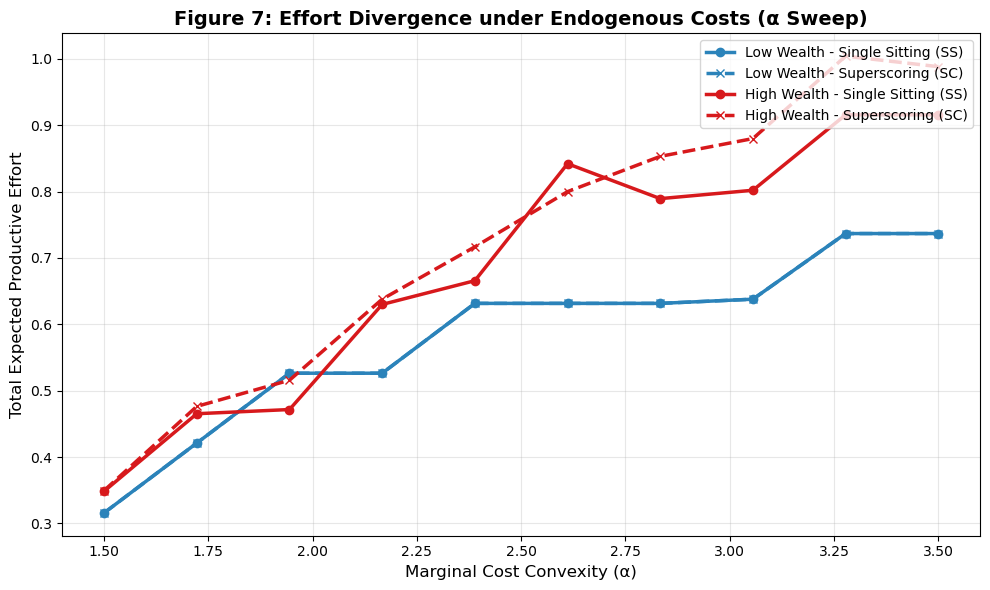

In [6]:
plot_alpha_sweep()

### FIGURE 8 — Distribution Shift (KDE)
Density of Final Scores: How the policy impacts each wealth class

SS and SC so far.

In [ ]:
def plot_kde_distribution_mods(sim_df, pct):
    df = sim_df.copy()
    
    df['wealth_tier'] = pd.qcut(df['wealth_pct'], q=3, labels=['Low Wealth', 'Mid', 'High Wealth'])
    df = df[df['wealth_tier'].isin(['Low Wealth', 'High Wealth'])].copy()
    df['wealth_tier'] = df['wealth_tier'].cat.remove_unused_categories()

    # only SS and SC at present
    df = df[df['rule'].isin(['SS', 'SC'])]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
    
    colors = {'SS': '#2166ac', 'SC': '#d73027'}

    # Low Wealth Students
    low_df = df[df['wealth_tier'] == 'Low Wealth']
    sns.kdeplot(data=low_df, x='mean_score', hue='rule', ax=axes[0],
                palette=colors, fill=True, alpha=0.4, common_norm=False, linewidth=2,
                hue_order=['SS', 'SC'])
    
    axes[0].set_title('Low Wealth: Policy Impact', fontsize=13, fontweight='bold')
    
    # High Wealth Students
    high_df = df[df['wealth_tier'] == 'High Wealth']
    sns.kdeplot(data=high_df, x='mean_score', hue='rule', ax=axes[1],
                palette=colors, fill=True, alpha=0.4, common_norm=False, linewidth=2,
                hue_order=['SS', 'SC'])
    
    axes[1].set_title('High Wealth: Policy Impact', fontsize=13, fontweight='bold')

    # Calculate separate cutoffs
    ss_cutoff = df[df['rule'] == 'SS']['mean_score'].quantile(0.85)
    sc_cutoff = df[df['rule'] == 'SC']['mean_score'].quantile(0.85)
    
    for ax in axes:
        # Draw SS Cutoff (Solid)
        ax.axvline(ss_cutoff, color='#2166ac', linestyle='-', linewidth=2, zorder=5, alpha=0.8)
        ax.text(ss_cutoff - 0.005, 0.5, f'SS Top {pct}%', rotation=90, 
                transform=ax.get_xaxis_transform(), fontsize=9, color='#2166ac',
                va='center', ha='right', fontweight='bold')        
        
        # Draw SC Cutoff (Dashed)
        ax.axvline(sc_cutoff, color='#d73027', linestyle='--', linewidth=2, zorder=5, alpha=0.8)
        ax.text(sc_cutoff + 0.005, 0.5, f'SC Top {pct}%', rotation=90, 
                transform=ax.get_xaxis_transform(), fontsize=9, color='#d73027',
                va='center', ha='left', fontweight='bold') 

    for ax in axes:
        ax.set_xlabel('Expected Final Score', fontsize=11)
        ax.set_ylabel('Density', fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.3)

    plt.suptitle(f'Figure 8: Asymmetric Impact of Superscoring, Top {pct}%', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.savefig(f'graphs_results/fig8_kde_distribution_{pct}.png', dpi=300, bbox_inches='tight')
    plt.close()
    print("Fig 8 (KDE) saved.")

In [58]:
plot_kde_distribution_mods(sim_df, 10)

Fig 8 (KDE) saved.


In [59]:
plot_kde_distribution_mods(sim_df, 15)

Fig 8 (KDE) saved.


### Plot 9: Effort Decomposition
By wealth class, by scoring rule, for two rounds

SC reduces Round 1 effort (Safety Net Effect) while increasing Round 2 effort for high wealth

In [ ]:
def plot_effort_decomposition(sim_df):
    df = sim_df.copy()
    df['wealth_tier'] = pd.qcut(df['wealth_pct'], q=3, labels=['Low', 'Mid', 'High'])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    
    for ax, rule in zip(axes, ['SS', 'SC']):
        sub = df[df['rule'] == rule]
        summary = sub.groupby('wealth_tier', observed=True)[['effort_r1', 'effort_r2']].mean()
        
        x = np.arange(3)
        bars1 = ax.bar(x - 0.2, summary['effort_r1'], 0.35, label='Round 1', color='#2166ac', alpha=0.85)
        bars2 = ax.bar(x + 0.2, summary['effort_r2'], 0.35, label='Round 2', color='#d73027', alpha=0.85)
        
        ax.bar_label(bars1, fmt='%.3f', padding=3, fontsize=9, fontweight='bold', color='#1a4a7e')
        
        # label Round 2 if > 0
        labels2 = [f"{v:.3f}" if v > 0.001 else "" for v in summary['effort_r2']]
        ax.bar_label(bars2, labels=labels2, padding=3, fontsize=9, fontweight='bold', color='#a3241d')

        ax.set_xticks(x)
        ax.set_xticklabels(['Low Wealth', 'Mid Wealth', 'High Wealth'])
        ax.set_title(f'{"Single-Sitting" if rule == "SS" else "Superscoring"}', fontweight='bold')
        ax.set_ylabel('Mean Effort')        
        ax.set_ylim(0, summary.max().max() * 1.20)
        ax.legend()
    
    plt.suptitle('Effort Decomposition by Round and Wealth',
                 fontsize=12)
    plt.tight_layout()
    plt.savefig('graphs_results/fig9_effort_decomp.png', dpi=150, bbox_inches='tight')
    plt.close()
    print("Fig 9: Effort Decomposition Figure saved.")

In [64]:
plot_effort_decomposition(sim_df)

Fig 9: Effort Decomposition Figure saved.


### Plot 10: Access Premium: Conditional Wealth Splitting

High-wealth students harvest the variance bonus regardless of ability. 'High Wealth' relative to peers in the same ability quartile

In [ ]:
def assign_conditional_wealth(group):
    median_wealth = group['wealth_pct'].median()
    group['wealth_group'] = np.where(group['wealth_pct'] >= median_wealth, 
                                     'Above-Median Wealth (Conditional)', 
                                     'Below-Median Wealth (Conditional)')
    return group

def plot_access_premium(sim_df):    
    ss = sim_df[sim_df['rule'] == 'SS'][['student_id', 'true_ability', 'wealth_pct', 'mean_score']].rename(columns={'mean_score': 'score_SS'})
    sc = sim_df[sim_df['rule'] == 'SC'][['student_id', 'mean_score']].rename(columns={'mean_score': 'score_SC'})
    
    # Access Premium Calc
    merged = ss.merge(sc, on='student_id')
    merged['premium'] = merged['score_SC'] - merged['score_SS']
    
    # True Ability Quartiles global
    merged['ability_q'] = pd.qcut(merged['true_ability'], q=4, labels=['Q1 (Lowest \u03B7)', 'Q2', 'Q3', 'Q4 (Highest \u03B7)'])
    merged = merged.groupby('ability_q', group_keys=False, observed=True).apply(assign_conditional_wealth)
    
    # Plotting
    fig, ax = plt.subplots(figsize=(10, 6))
    summary = merged.groupby(['ability_q', 'wealth_group'], observed=True)['premium'].mean().unstack()
    
    # Order the columns for consistent coloring
    cols = ['Above-Median Wealth (Conditional)', 'Below-Median Wealth (Conditional)']
    summary = summary[cols]
    
    summary.plot(kind='bar', ax=ax, color=['#d7191c', '#2b83ba'], alpha=0.85, edgecolor='black', width=0.6)
    
    # Annotations
    for container in ax.containers:
        ax.bar_label(container, fmt='+%.3f', padding=3, fontsize=10, fontweight='bold')
    
    ax.set_ylim(0, summary.max().max() * 1.25)
    ax.axhline(0, color='black', lw=1)
    
    ax.set_xlabel('True Baseline Ability Quartile', fontsize=12, labelpad=10)
    ax.set_ylabel('Access Premium (\u0394 Score Boost)', fontsize=12)
    ax.set_title('Figure 10: Conditionally Balanced Access Premium', 
                 fontsize=14, fontweight='bold', pad=15)
    
    ax.legend(title='Relative Wealth within Quartile', loc='upper right', bbox_to_anchor=(1.0, 1.0))
    plt.xticks(rotation=0)
    ax.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('graphs_results/fig10_access_premium.png', dpi=150, bbox_inches='tight')
    plt.show()


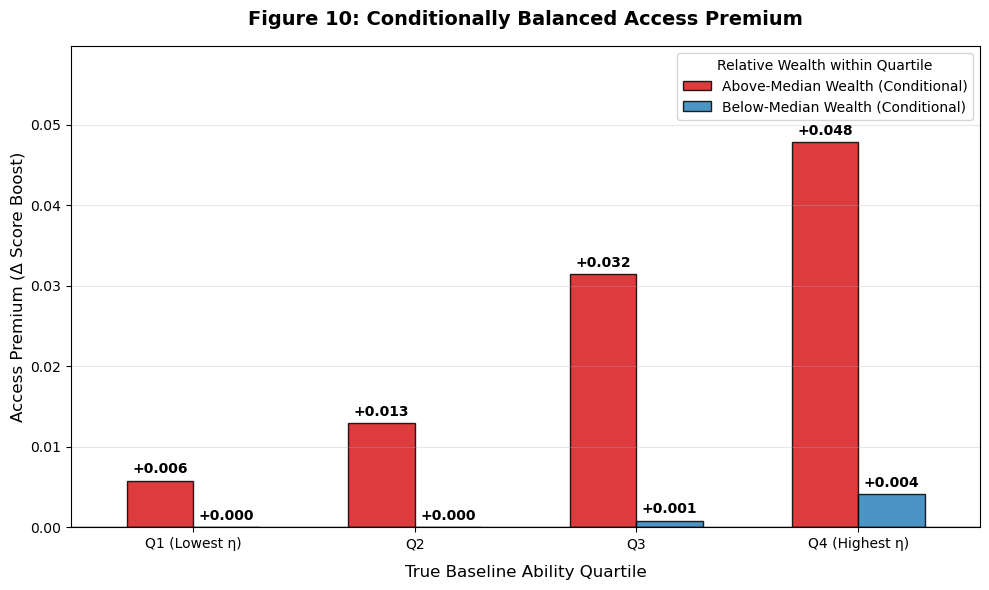

In [8]:
plot_access_premium(sim_df)

### Plot 11

Behavioral validation of prop 6 (Fixed Cost Monotonicity).

In [32]:
def plot_retake_behavior(sim_df):
    """
    Wealth relaxes the retake budget constraint.
    """
    # sub-dataframe with only SS and SC to show baseline contrast
    sub = sim_df[sim_df['rule'].isin(['SS', 'SC'])].copy()
    
    # Wealth groups: low, mid, high
    sub['wealth_tier'] = pd.qcut(sub['wealth_pct'], q=3, labels=['Low Wealth', 'Mid Wealth', 'High Wealth'])
    
    # average retake rate
    rates = sub.groupby(['wealth_tier', 'rule'], observed=True)['retake_rate'].mean().reset_index()
    rates['retake_rate'] *= 100 
    
    fig, ax = plt.subplots(figsize=(9, 6))
    sns.barplot(data=rates, x='wealth_tier', y='retake_rate', hue='rule', 
                palette=['#2b83ba', '#d7191c'], edgecolor='black', ax=ax)
    
    ax.set_title('Retake Rates by Wealth Tier', fontsize=14, fontweight='bold')
    ax.set_xlabel('Socioeconomic Cohort', fontsize=12)
    ax.set_ylabel('Probability of Retaking (%)', fontsize=12)
    ax.legend(title='Scoring Regime')
    ax.grid(axis='y', alpha=0.3)
    
    # label bars with exact percentages
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f'{height:.1f}%', (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3), textcoords='offset points')

    plt.tight_layout()
    plt.savefig('graphs_results/fig11_retake_behavior.png', dpi=150)
    plt.show()

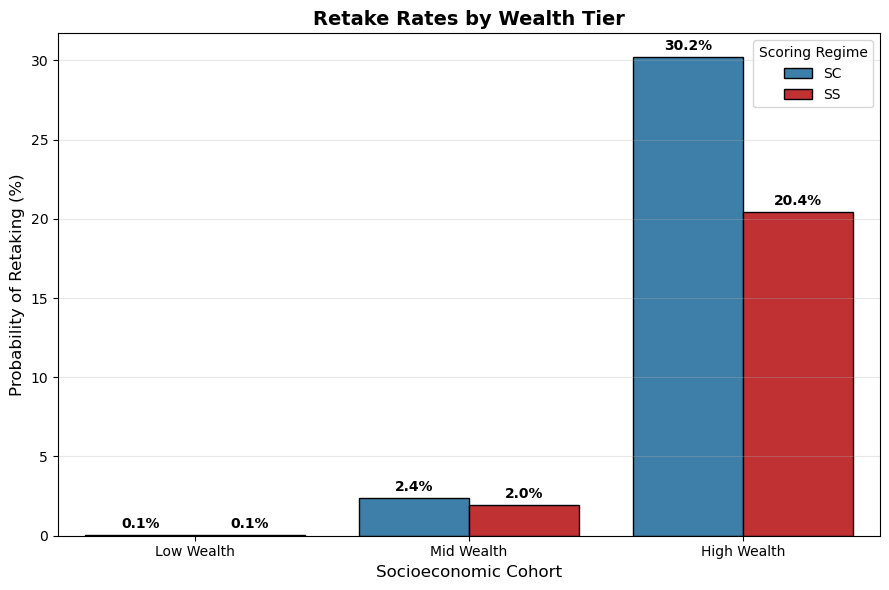

In [33]:
plot_retake_behavior(sim_df)